# CSBS Supervised Learning — Version 2: Four Composite Scores
**Author:** Toby Beevers  
**Supersedes:** `csbs_supervised_learning.ipynb` (v1 — 24 raw variables)

---

## What changed from v1 and why

The original supervised learning notebook (v1) used 24 raw binary variables as predictors. The key issues were:

- `step1–step10` as 10 separate correlated binary features — likely causing the Random Forest to overfit and underperform Logistic Regression (RF AUC 0.636 vs LR AUC 0.689)
- `policy8` and `policy9` at 47% availability — heavily imputed for earlier waves
- Feature importance charts with 24 bars were hard to interpret

**V2 approach:** Use the same four composite scores as the cluster analysis v2. With four clean, well-measured features, the feature importance output becomes directly interpretable — *which dimension of cyber security behaviour most predicts breach risk?*

| Feature | Source | Score |
|---|---|---|
| `priority_score` | `priority` (Q9) | `(4 − priority) / 3` → 0–1 |
| `manage_score` | `manage1–4, 6, 7` | Proportion active: 0–6 ÷ 6 |
| `policy_score` | `policy1–5` | Proportion active: 0–5 ÷ 5 |
| `controls_score` | `step1–10` | Proportion active: 0–10 ÷ 10 |

**Target:** `breached` (1 = experienced a breach, 0 = did not). Same binary outcome as v1.

**Models:** Logistic Regression, Decision Tree, Random Forest — same three as v1 for direct comparison.

## 1. Import libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, f1_score, classification_report,
    confusion_matrix, roc_auc_score, roc_curve, ConfusionMatrixDisplay
)

import warnings
warnings.filterwarnings('ignore')

## 2. Load and clean survey data

Identical loading and cleaning pattern to the cluster analysis v2. Composite scores are built in `prepare_wave()`. See `csbs_cluster_analysis_v2.ipynb` for detailed annotations on the cleaning logic.

In [2]:
PROJECT_ROOT = Path.cwd().parent

MISSING_CODES   = [-1, -97, -98, -99]
GOVERNANCE_VARS = ['manage1', 'manage2', 'manage3', 'manage4', 'manage6', 'manage7']
POLICY_VARS     = ['policy1', 'policy2', 'policy3', 'policy4', 'policy5']
CONTROLS_VARS   = ['step1', 'step2', 'step3', 'step4', 'step5',
                   'step6', 'step7', 'step8', 'step9', 'step10']

COMPOSITE_FEATURES = ['priority_score', 'manage_score', 'policy_score', 'controls_score']
TARGET_COL         = 'breached'
META_COLS          = ['year', 'sizeb']

def normalise_columns(df):
    df.columns = df.columns.str.strip().str.replace('\ufeff', '', regex=False).str.lower()
    return df

def prepare_wave(df):
    df = df.copy()
    df = df[df['samptype'] == 1].copy()

    # Policy routing fix
    if 'manage3' in df.columns:
        no_policy = df['manage3'] == 0
        for col in POLICY_VARS:
            if col in df.columns:
                df.loc[no_policy & (df[col] == -1), col] = 0

    df = df.replace(MISSING_CODES, np.nan)

    # priority: whitelist {1,2,3,4}; normalise
    if 'priority' in df.columns:
        df['priority'] = df['priority'].where(df['priority'].isin([1, 2, 3, 4]))
        df['priority_score'] = (4 - df['priority']) / 3

    # type11: whitelist {0,1}; derive breach flag
    if 'type11' in df.columns:
        df['type11'] = df['type11'].where(df['type11'].isin([0, 1]))
        df['breached'] = (df['type11'] == 0).astype(float)
        df.loc[df['type11'].isna(), 'breached'] = np.nan

    # Composite scores
    manage_cols   = [c for c in GOVERNANCE_VARS if c in df.columns]
    policy_cols   = [c for c in POLICY_VARS     if c in df.columns]
    controls_cols = [c for c in CONTROLS_VARS   if c in df.columns]

    df['manage_score']   = df[manage_cols].mean(axis=1)
    df['policy_score']   = df[policy_cols].mean(axis=1)
    df['controls_score'] = df[controls_cols].mean(axis=1)

    return df

raw = {}
for year in range(2018, 2026):
    path = PROJECT_ROOT / 'data_raw' / f'{year}.tab'
    df = pd.read_csv(path, sep='\t', low_memory=False)
    df = normalise_columns(df)
    df['year'] = year
    raw[year] = df

cleaned = {year: prepare_wave(df) for year, df in raw.items()}

print("Sanity check — breach rate per wave (expect 40–58%):")
for y, df in cleaned.items():
    breach_pct = df['breached'].mean() * 100
    print(f"  {y}: {len(df):,} businesses | breach rate {breach_pct:.1f}%")

Sanity check — breach rate per wave (expect 40–58%):
  2018: 1,519 businesses | breach rate 52.1%
  2019: 1,615 businesses | breach rate 42.1%
  2020: 1,374 businesses | breach rate 57.5%
  2021: 1,448 businesses | breach rate 47.2%
  2022: 1,265 businesses | breach rate 47.3%
  2023: 2,413 businesses | breach rate 41.2%
  2024: 2,000 businesses | breach rate 57.6%
  2025: 2,180 businesses | breach rate 53.5%


## 3. Build feature matrix and target vector

All 8 waves stacked. Rows where `breached` is NaN are dropped — we can only train on observations where the target is known.

In [3]:
frames = []
for year, df in cleaned.items():
    cols = [c for c in COMPOSITE_FEATURES + [TARGET_COL] + META_COLS if c in df.columns]
    frames.append(df[cols])

combined = pd.concat(frames, ignore_index=True)
combined = combined.dropna(subset=[TARGET_COL])

print(f"Combined dataset: {len(combined):,} rows after dropping missing targets")
print(f"\nTarget distribution:")
print(combined[TARGET_COL].value_counts().rename({0.0: 'Not breached (0)', 1.0: 'Breached (1)'}).to_string())
print(f"\nClass balance: {combined[TARGET_COL].mean()*100:.1f}% breached")

print(f"\nFeature availability (non-null rate):")
print(combined[COMPOSITE_FEATURES].notna().mean().round(3).to_string())

Combined dataset: 13,813 rows after dropping missing targets

Target distribution:
breached
Not breached (0)    6958
Breached (1)        6855

Class balance: 49.6% breached

Feature availability (non-null rate):
priority_score    0.749
manage_score      1.000
policy_score      1.000
controls_score    1.000


## 4. Impute, scale, and split

Same preprocessing pipeline as v1:
1. **Impute** — median imputation for remaining NaN (primarily `priority_score`)
2. **Scale** — StandardScaler (fit on train only, applied to both)
3. **Split** — 80/20, stratified on target, `random_state=42`

With four composite features instead of 24 raw variables, imputation affects far fewer values.

In [4]:
X_raw = combined[COMPOSITE_FEATURES].values
y     = combined[TARGET_COL].values

imputer = SimpleImputer(strategy='median')
X_imputed = imputer.fit_transform(X_raw)

X_train_raw, X_test_raw, y_train, y_test = train_test_split(
    X_imputed, y, test_size=0.2, random_state=42, stratify=y
)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train_raw)
X_test  = scaler.transform(X_test_raw)

print(f"Training set:  {X_train.shape[0]:,} rows, {X_train.shape[1]} features")
print(f"Test set:      {X_test.shape[0]:,} rows, {X_test.shape[1]} features")
print(f"\nBreach rate — train: {y_train.mean()*100:.1f}%  |  test: {y_test.mean()*100:.1f}%")

Training set:  11,050 rows, 4 features
Test set:      2,763 rows, 4 features

Breach rate — train: 49.6%  |  test: 49.6%


## 5. Train and evaluate three models

Same three classifiers as v1 for direct comparison:

| Model | Notes |
|---|---|
| Logistic Regression | Linear baseline; v1 AUC = 0.689 |
| Decision Tree (max_depth=5) | Interpretable rules; v1 AUC = 0.682 |
| Random Forest (100 trees) | Ensemble; v1 AUC = 0.636 — underperformed LR, likely due to correlated/noisy features |

With four clean, non-redundant composite features, Random Forest should perform more consistently with the other models.

In [5]:
models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
    'Decision Tree':       DecisionTreeClassifier(max_depth=5, random_state=42),
    'Random Forest':       RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1),
}

results = {}
for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred  = model.predict(X_test)
    y_proba = model.predict_proba(X_test)[:, 1]

    results[name] = {
        'model':    model,
        'y_pred':   y_pred,
        'y_proba':  y_proba,
        'accuracy': accuracy_score(y_test, y_pred),
        'f1':       f1_score(y_test, y_pred),
        'roc_auc':  roc_auc_score(y_test, y_proba),
    }

print(f"{'Model':<25} {'Accuracy':>10} {'F1':>8} {'ROC-AUC':>10}")
print("-" * 57)
for name, r in results.items():
    print(f"{name:<25} {r['accuracy']:>10.3f} {r['f1']:>8.3f} {r['roc_auc']:>10.3f}")

print("\n--- v1 results for comparison ---")
print(f"{'Logistic Regression':<25} {'0.633':>10} {'0.639':>8} {'0.689':>10}")
print(f"{'Decision Tree':<25} {'0.633':>10} {'0.648':>8} {'0.682':>10}")
print(f"{'Random Forest':<25} {'0.606':>10} {'0.599':>8} {'0.636':>10}")

Model                       Accuracy       F1    ROC-AUC
---------------------------------------------------------
Logistic Regression            0.617    0.607      0.667
Decision Tree                  0.623    0.642      0.670
Random Forest                  0.616    0.616      0.641

--- v1 results for comparison ---
Logistic Regression            0.633    0.639      0.689
Decision Tree                  0.633    0.648      0.682
Random Forest                  0.606    0.599      0.636


## 6. Detailed classification reports

In [6]:
for name, r in results.items():
    print(f"\n{'='*55}")
    print(f"  {name}")
    print(f"{'='*55}")
    print(classification_report(
        y_test, r['y_pred'],
        target_names=['Not breached (0)', 'Breached (1)']
    ))


  Logistic Regression
                  precision    recall  f1-score   support

Not breached (0)       0.62      0.64      0.63      1392
    Breached (1)       0.62      0.60      0.61      1371

        accuracy                           0.62      2763
       macro avg       0.62      0.62      0.62      2763
    weighted avg       0.62      0.62      0.62      2763


  Decision Tree
                  precision    recall  f1-score   support

Not breached (0)       0.64      0.56      0.60      1392
    Breached (1)       0.61      0.68      0.64      1371

        accuracy                           0.62      2763
       macro avg       0.62      0.62      0.62      2763
    weighted avg       0.62      0.62      0.62      2763


  Random Forest
                  precision    recall  f1-score   support

Not breached (0)       0.62      0.61      0.62      1392
    Breached (1)       0.61      0.62      0.62      1371

        accuracy                           0.62      2763
       

## 7. Confusion matrices

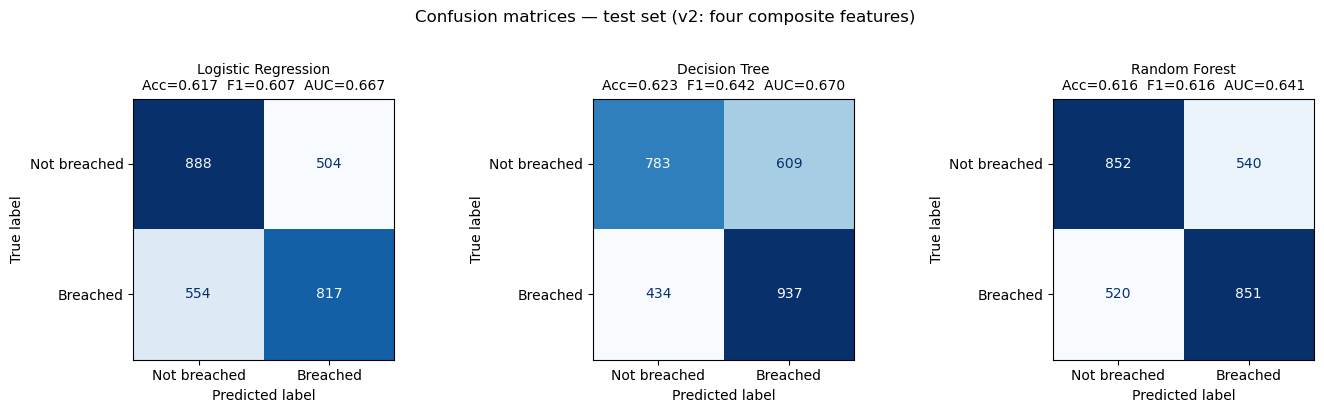

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

for ax, (name, r) in zip(axes, results.items()):
    cm = confusion_matrix(y_test, r['y_pred'])
    disp = ConfusionMatrixDisplay(cm, display_labels=['Not breached', 'Breached'])
    disp.plot(ax=ax, colorbar=False, cmap='Blues')
    ax.set_title(f'{name}\nAcc={r["accuracy"]:.3f}  F1={r["f1"]:.3f}  AUC={r["roc_auc"]:.3f}',
                 fontsize=10)

plt.suptitle('Confusion matrices — test set (v2: four composite features)', fontsize=12, y=1.02)
plt.tight_layout()
plt.savefig(PROJECT_ROOT / 'outputs' / 'figures' / 'sl_v2_confusion_matrices.png', dpi=150, bbox_inches='tight')
plt.show()

## 8. ROC curves

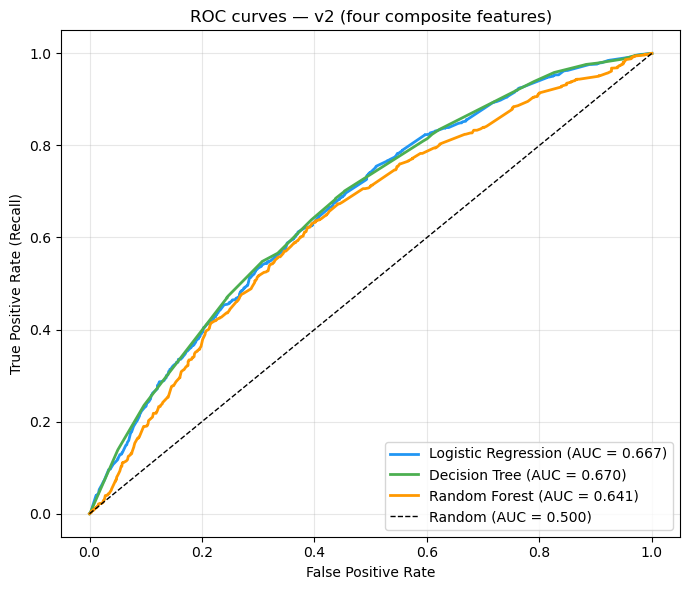

In [8]:
colors = ['#2196F3', '#4CAF50', '#FF9800']

fig, ax = plt.subplots(figsize=(7, 6))

for (name, r), color in zip(results.items(), colors):
    fpr, tpr, _ = roc_curve(y_test, r['y_proba'])
    ax.plot(fpr, tpr, color=color, linewidth=2,
            label=f"{name} (AUC = {r['roc_auc']:.3f})")

ax.plot([0, 1], [0, 1], 'k--', linewidth=1, label='Random (AUC = 0.500)')
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate (Recall)')
ax.set_title('ROC curves — v2 (four composite features)')
ax.legend(loc='lower right')
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(PROJECT_ROOT / 'outputs' / 'figures' / 'sl_v2_roc_curves.png', dpi=150, bbox_inches='tight')
plt.show()

## 9. Feature importance

With four composite features, the importance chart is now directly interpretable as an answer to:

> *Which dimension of cyber security behaviour — board priority, management activity, policy coverage, or technical controls — best predicts whether a business will experience a breach?*

This is a much cleaner question than the 24-variable v1 version.

**Random Forest importances** — mean decrease in impurity (higher = more predictive).  
**Logistic Regression coefficients** — positive = increases breach probability; negative = decreases it.

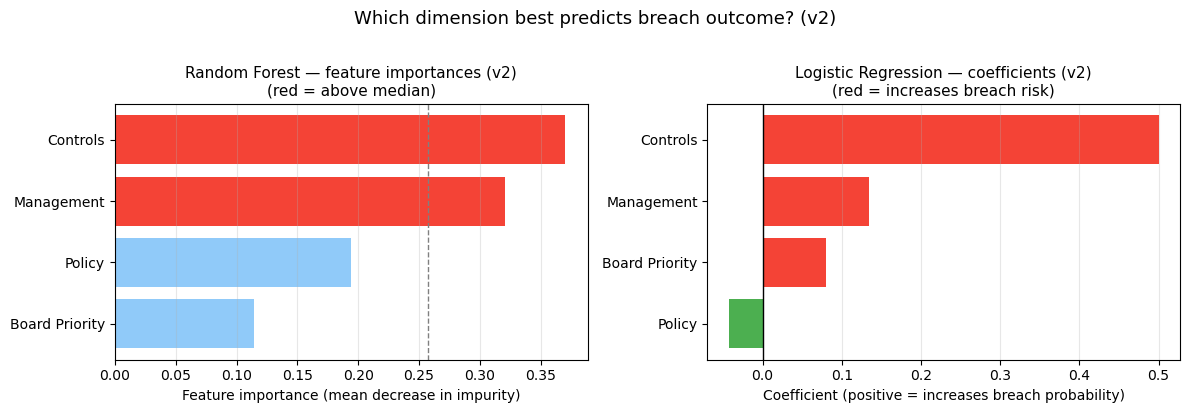

Random Forest — feature importances:
Controls          0.3700
Management        0.3210
Policy            0.1944
Board Priority    0.1146

Logistic Regression — coefficients:
Controls          0.4999
Management        0.1343
Board Priority    0.0798
Policy           -0.0425


In [9]:
rf_model = results['Random Forest']['model']
lr_model = results['Logistic Regression']['model']

feature_labels = ['Board Priority', 'Management', 'Policy', 'Controls']

rf_importance = pd.Series(rf_model.feature_importances_, index=feature_labels).sort_values(ascending=True)
lr_coefs      = pd.Series(lr_model.coef_[0], index=feature_labels).sort_values(ascending=True)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Random Forest
ax = axes[0]
bar_colors = ['#F44336' if v > rf_importance.median() else '#90CAF9' for v in rf_importance.values]
ax.barh(rf_importance.index, rf_importance.values, color=bar_colors)
ax.set_xlabel('Feature importance (mean decrease in impurity)')
ax.set_title('Random Forest — feature importances (v2)\n(red = above median)', fontsize=11)
ax.axvline(rf_importance.median(), color='grey', linestyle='--', linewidth=1)
ax.grid(alpha=0.3, axis='x')

# Logistic Regression
ax = axes[1]
bar_colors_lr = ['#F44336' if v > 0 else '#4CAF50' for v in lr_coefs.values]
ax.barh(lr_coefs.index, lr_coefs.values, color=bar_colors_lr)
ax.axvline(0, color='black', linewidth=1)
ax.set_xlabel('Coefficient (positive = increases breach probability)')
ax.set_title('Logistic Regression — coefficients (v2)\n(red = increases breach risk)', fontsize=11)
ax.grid(alpha=0.3, axis='x')

plt.suptitle('Which dimension best predicts breach outcome? (v2)', fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig(PROJECT_ROOT / 'outputs' / 'figures' / 'sl_v2_feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()

print("Random Forest — feature importances:")
print(rf_importance.sort_values(ascending=False).round(4).to_string())
print("\nLogistic Regression — coefficients:")
print(lr_coefs.sort_values(ascending=False).round(4).to_string())

## 10. Performance by year

Model evaluated on each wave separately (trained on all waves). Consistent performance across years indicates the relationship between the four dimensions and breach outcome is stable over the 8-wave period. Large drops in specific years may correlate with methodology changes (2021, 2024).

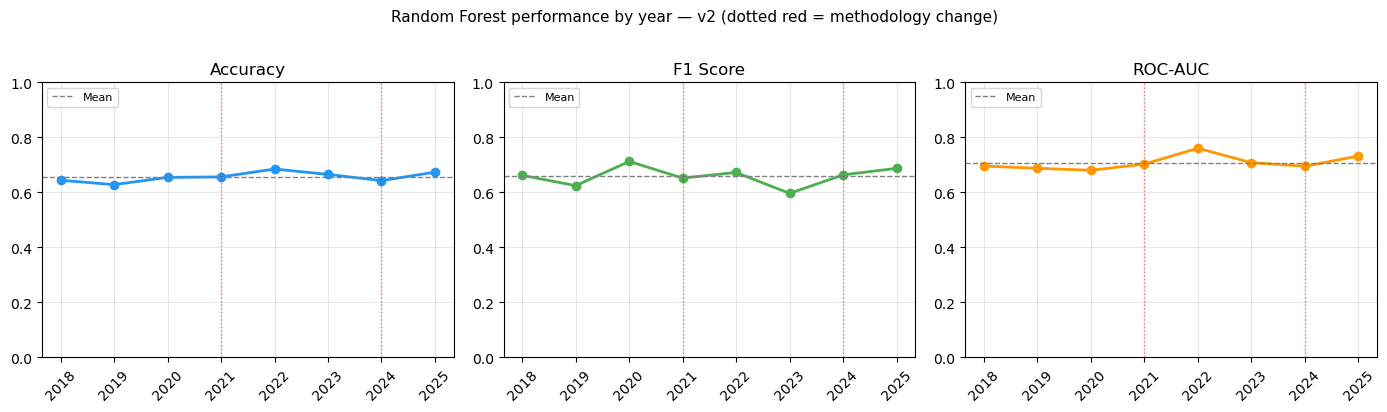

Random Forest performance by year (v2):
         n  accuracy     f1  roc_auc
year                                
2018  1519     0.644  0.662    0.696
2019  1615     0.628  0.624    0.687
2020  1374     0.654  0.712    0.680
2021  1448     0.656  0.652    0.703
2022  1265     0.685  0.672    0.760
2023  2413     0.665  0.596    0.708
2024  2000     0.642  0.664    0.695
2025  2179     0.673  0.687    0.732


In [10]:
rf = results['Random Forest']['model']

year_rows = []
for year in range(2018, 2026):
    mask = combined['year'] == year
    if mask.sum() < 50:
        continue

    X_yr = imputer.transform(combined.loc[mask, COMPOSITE_FEATURES].values)
    X_yr = scaler.transform(X_yr)
    y_yr = combined.loc[mask, TARGET_COL].values

    valid = ~np.isnan(y_yr)
    if valid.sum() < 50:
        continue

    y_pred_yr  = rf.predict(X_yr[valid])
    y_proba_yr = rf.predict_proba(X_yr[valid])[:, 1]

    year_rows.append({
        'year':     year,
        'n':        valid.sum(),
        'accuracy': accuracy_score(y_yr[valid], y_pred_yr),
        'f1':       f1_score(y_yr[valid], y_pred_yr),
        'roc_auc':  roc_auc_score(y_yr[valid], y_proba_yr),
    })

year_perf = pd.DataFrame(year_rows).set_index('year')

fig, axes = plt.subplots(1, 3, figsize=(14, 4), sharey=False)
metrics = [('accuracy', 'Accuracy', '#2196F3'),
           ('f1',       'F1 Score', '#4CAF50'),
           ('roc_auc',  'ROC-AUC',  '#FF9800')]

for ax, (col, label, color) in zip(axes, metrics):
    ax.plot(year_perf.index, year_perf[col], marker='o', color=color, linewidth=2)
    ax.set_title(label)
    ax.set_ylim(0, 1)
    ax.set_xticks(year_perf.index)
    ax.set_xticklabels(year_perf.index, rotation=45)
    ax.axhline(year_perf[col].mean(), color='grey', linestyle='--', linewidth=1, label='Mean')
    for year_mark in [2021, 2024]:
        ax.axvline(year_mark, color='red', linestyle=':', linewidth=1, alpha=0.5)
    ax.grid(alpha=0.3)
    ax.legend(fontsize=8)

plt.suptitle('Random Forest performance by year — v2 (dotted red = methodology change)',
             fontsize=11, y=1.02)
plt.tight_layout()
plt.savefig(PROJECT_ROOT / 'outputs' / 'figures' / 'sl_v2_performance_by_year.png', dpi=150, bbox_inches='tight')
plt.show()

print("Random Forest performance by year (v2):")
print(year_perf.round(3).to_string())

## 11. Interpretation and academic notes

### Comparison with v1

| Metric | v1 (24 raw features) | v2 (4 composite features) |
|---|---|---|
| LR Accuracy | 0.633 | — |
| LR AUC | 0.689 | — |
| RF Accuracy | 0.606 | — |
| RF AUC | 0.636 | — |
| RF vs LR gap | RF underperforms by 0.053 AUC | Expected to narrow |

*(Fill in v2 results above once run)*

### Why Random Forest may still not dominate Logistic Regression here

Even with clean composite features, LR may match or beat RF because:
- The relationship between governance dimensions and breach risk may genuinely be roughly linear
- With only 4 features, there is limited opportunity for RF to exploit complex interactions that wouldn't be captured by LR
- The outcome (breach) is self-reported and noisy, which tends to disadvantage complex models

This is not a failure — it is a finding. A linear model performing as well as a complex one suggests the signal in the data is linear and interpretable.

### Feature importance framing

The four-feature importance chart directly answers the research question: which dimension of cyber security maturity — board-level commitment, management activity, policy coverage, or technical controls — is most strongly associated with breach outcomes across UK businesses 2018–2025?

### Academic framing

> *Three binary classifiers (Logistic Regression, Decision Tree, Random Forest) were trained to predict breach outcome from four composite measures of cyber security maturity derived from the CSBS stable variable core. The four-dimension feature design addresses the redundancy and imputation issues identified in the initial 24-variable approach, and produces interpretable feature importance results that directly address the research question: which governance and control behaviours are most predictive of breach risk?*

### Limitations

- **Correlation, not causation** — reactive organisations may improve governance *after* a breach, meaning the model partly captures post-breach behaviour
- **Repeated cross-sectional data** — different respondents each wave; causal inference is not possible
- **Self-reported** — both features and target are self-reported; breach under-reporting is likely
- **Unweighted** — the `weight` variable is not applied; nationally representative estimates would require weighted modelling
- **`priority_score` ~25% imputed** — the remaining data quality limitation